# 🎓 Training Pipeline – Integral Action Classifier
Xử lý dữ liệu mất cân bằng và tối ưu hiệu suất model.

In [1]:
import pandas as pd
import sys, os, re
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../..'))

%pip install matplotlib scikit-learn imbalanced-learn -q

from collections import Counter
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from ai.utils.integral import Integral
from ai.utils.printer import Printer
from ai.utils.expr.expr_node import ExprNode
from ai.utils.expr.trig.expr_sin import SinExprNode
from ai.utils.expr.trig.expr_cos import CosExprNode
from ai.utils.expr.trig.expr_tan import TanExprNode
from ai.utils.expr.operation.expr_add import AddExprNode
from ai.utils.expr.operation.expr_sub import SubExprNode
from ai.utils.expr.operation.expr_mul import MulExprNode
from ai.utils.expr.operation.expr_frac import FracExprNode
from ai.utils.expr.value.expr_var import VarExprNode
from ai.utils.expr.value.expr_const import ConstExprNode
from ai.utils.expr.Power.expr_mono import MonoExprNode
from ai.utils.expr.expr_log import LogExprNode
from ai.utils.expr.Power.expr_sqrt import SqrtExprNode
from ai.utils.expr.Power.expr_power import PowerExprNode

print('✅ Project imports OK')

✅ Project imports OK


## 📊 1. Load & Phân tích dữ liệu

📦 Tổng mẫu: 2130
📐 Features: 104
🏷️  Classes: [0, 1, 2, 3, 4, 5]

📊 Phân phối nhãn:
  action=0: 168 (7.9%)
  action=1: 417 (19.6%)
  action=2: 430 (20.2%)
  action=3: 404 (19.0%)
  action=4: 363 (17.0%)
  action=5: 348 (16.3%)


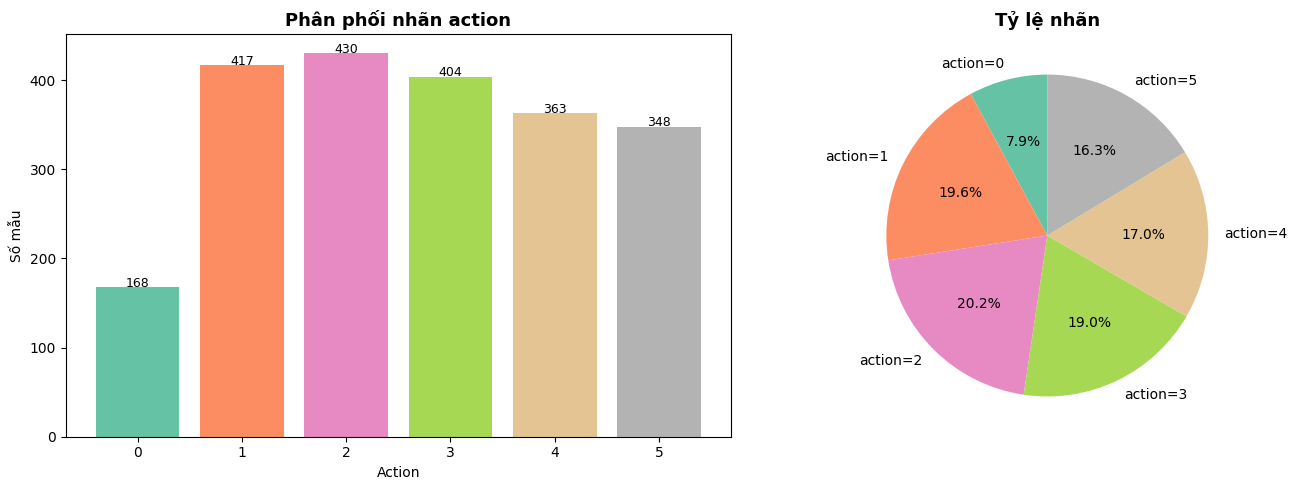

💾 Đã lưu label_distribution.png


In [3]:
df = pd.read_csv('../data/processed/integral_dataset.csv')
# df = df.head(2500)

# Đảm bảo label là số nguyên
df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
df = df.dropna(subset=['label'])

y = df['label'].astype(int)
X = df.drop(columns=['label'])

print(f'📦 Tổng mẫu: {len(df)}')
print(f'📐 Features: {X.shape[1]}')
print(f'🏷️  Classes: {sorted(y.unique())}')

cnt = Counter(y)
print('\n📊 Phân phối nhãn:')
for k in sorted(cnt): 
    print(f'  action={k}: {cnt[k]} ({cnt[k]/len(y)*100:.1f}%)')

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = sorted(cnt.keys())
values = [cnt[k] for k in labels]
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

axes[0].bar([str(l) for l in labels], values, color=colors)
axes[0].set_title('Phân phối nhãn action', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('Số mẫu')
for i, v in enumerate(values):
    axes[0].text(i, v+0.2, str(v), ha='center', fontsize=9)

axes[1].pie(values, labels=[f'action={l}' for l in labels],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Tỷ lệ nhãn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('💾 Đã lưu label_distribution.png')

## ⚖️ 2. Xử lý mất cân bằng – Class Weights

In [4]:
classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=classes, y=y)
cw_dict = dict(zip(classes, class_weights))

print('⚖️  Class weights (balanced):')
for k in sorted(cw_dict):
    bar = '█' * int(cw_dict[k])
    print(f'  action={k:3d}: {cw_dict[k]:.3f}  {bar}')

⚖️  Class weights (balanced):
  action=  0: 2.113  ██
  action=  1: 0.851  
  action=  2: 0.826  
  action=  3: 0.879  
  action=  4: 0.978  
  action=  5: 1.020  █


## ✂️ 4. Train/Test Split (Stratified)

In [5]:
y_clean = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print(f'🔀 Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu')

# Tính class weights trên tập train
classes_train = np.unique(y_train)
cw_train = compute_class_weight('balanced', classes=classes_train, y=y_train)
cw_dict_train = dict(zip(classes_train, cw_train))
print(f'⚖️  Class weights train: {cw_dict_train}')

🔀 Train: 1704 mẫu | Test: 426 mẫu
⚖️  Class weights train: {0: 2.1194029850746268, 1: 0.8502994011976048, 2: 0.8255813953488372, 3: 0.8792569659442725, 4: 0.9793103448275862, 5: 1.017921146953405}


## 🤖 5. Model 1: SVM với Class Weight Balanced

In [6]:
# Số fold tự động theo class nhỏ nhất
min_count = min(Counter(y_train).values())
n_splits = min(5, min_count)
print(f'ℹ️  Dùng {n_splits}-fold CV (min class count = {min_count})')

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

param_grid_svm = [
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto', 0.01, 0.1]},
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10]},
    {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 10], 'svm__degree': [2, 3]}
]

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

gs_svm = GridSearchCV(
    svm_pipeline, param_grid_svm, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=0
)

print('🔍 Đang chạy GridSearchCV SVM...')
gs_svm.fit(X_train, y_train)
print(f'\n🏆 SVM Best params: {gs_svm.best_params_}')
print(f'🏆 SVM Best CV F1-macro: {gs_svm.best_score_:.4f}')

y_pred_svm = gs_svm.predict(X_test)
f1_svm = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)
print(f'\n📊 SVM Test F1-macro: {f1_svm:.4f}')
print(classification_report(y_test, y_pred_svm, zero_division=0))

ℹ️  Dùng 5-fold CV (min class count = 134)
🔍 Đang chạy GridSearchCV SVM...

🏆 SVM Best params: {'svm__C': 100, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
🏆 SVM Best CV F1-macro: 0.8220

📊 SVM Test F1-macro: 0.8349
              precision    recall  f1-score   support

         0.0       0.68      0.74      0.70        34
         1.0       0.84      0.87      0.85        83
         2.0       0.94      0.84      0.88        86
         3.0       0.80      0.95      0.87        81
         4.0       0.93      0.70      0.80        73
         5.0       0.87      0.94      0.90        69

    accuracy                           0.85       426
   macro avg       0.84      0.84      0.83       426
weighted avg       0.86      0.85      0.85       426



## 🌲 6. Model 2: Random Forest (tốt với imbalanced)

In [7]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    rf_pipeline, param_grid_rf, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=0
)

print('🔍 Đang chạy GridSearchCV Random Forest...')
gs_rf.fit(X_train, y_train)
print(f'\n🏆 RF Best params: {gs_rf.best_params_}')
print(f'🏆 RF Best CV F1-macro: {gs_rf.best_score_:.4f}')

y_pred_rf = gs_rf.predict(X_test)
# f1_rf = f1_score(y_test, y_pred_rf, average='macro', zero_vision=0)
# print(f'\n📊 RF Test F1-macro: {f1_rf:.4f}')
# print(classification_report(y_test, y_pred_rf, zero_division=0))

🔍 Đang chạy GridSearchCV Random Forest...

🏆 RF Best params: {'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
🏆 RF Best CV F1-macro: 0.8234


## 🚀 7. Model 3: Gradient Boosting

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

# Sample weights từ class_weight
sample_weights = np.array([cw_dict_train.get(label, 1.0) for label in y_train])

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, random_state=42
)

print('🔍 Đang train Gradient Boosting...')
gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test)
f1_gb = f1_score(y_test, y_pred_gb, average='macro', zero_division=0)
print(f'\n📊 GB Test F1-macro: {f1_gb:.4f}')
print(classification_report(y_test, y_pred_gb, zero_division=0))

🔍 Đang train Gradient Boosting...

📊 GB Test F1-macro: 0.8415
              precision    recall  f1-score   support

         0.0       0.65      0.76      0.70        34
         1.0       0.89      0.87      0.88        83
         2.0       0.94      0.85      0.89        86
         3.0       0.81      0.95      0.88        81
         4.0       0.91      0.71      0.80        73
         5.0       0.87      0.94      0.90        69

    accuracy                           0.86       426
   macro avg       0.84      0.85      0.84       426
weighted avg       0.86      0.86      0.86       426



## 🧬 8. SMOTE – Oversampling nhãn thiểu số

Tạo thêm mẫu tổng hợp cho các class ít dữ liệu.

In [11]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    # SMOTE chỉ hoạt động khi mỗi class có ít nhất 2 mẫu
    cnt_train = Counter(y_train)
    valid_classes = [k for k, v in cnt_train.items() if v >= 2]
    mask = y_train.isin(valid_classes)
    X_tr_sm, y_tr_sm = X_train[mask], y_train[mask]

    k_neighbors = min(3, min(Counter(y_tr_sm).values()) - 1)
    smote = SMOTE(k_neighbors=max(1, k_neighbors), random_state=42)
    X_res, y_res = smote.fit_resample(X_tr_sm, y_tr_sm)

    print(f'✅ SMOTE: {len(y_tr_sm)} → {len(y_res)} mẫu')
    print('Phân phối sau SMOTE:', Counter(y_res))

    # Train SVM trên dữ liệu SMOTE
    svm_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(class_weight='balanced', probability=True, random_state=42,
                    kernel='rbf', C=10, gamma='scale'))
    ])
    svm_smote.fit(X_res, y_res)
    y_pred_smote = svm_smote.predict(X_test)
    f1_smote = f1_score(y_test, y_pred_smote, average='macro', zero_division=0)
    print(f'\n📊 SVM+SMOTE Test F1-macro: {f1_smote:.4f}')
    print(classification_report(y_test, y_pred_smote, zero_division=0))

except ImportError:
    f1_smote = 0
    print('⚠️  imbalanced-learn chưa cài. Chạy: pip install imbalanced-learn')

✅ SMOTE: 1704 → 2064 mẫu
Phân phối sau SMOTE: Counter({5: 344, 4: 344, 1: 344, 3: 344, 2: 344, 0: 344})

📊 SVM+SMOTE Test F1-macro: 0.8209
              precision    recall  f1-score   support

         0.0       0.67      0.76      0.71        34
         1.0       0.83      0.89      0.86        83
         2.0       0.94      0.84      0.88        86
         3.0       0.75      0.96      0.84        81
         4.0       0.92      0.60      0.73        73
         5.0       0.90      0.90      0.90        69

    accuracy                           0.84       426
   macro avg       0.83      0.83      0.82       426
weighted avg       0.85      0.84      0.83       426



## 🏅 9. So sánh các Model


🏅 BẢNG SO SÁNH MODEL
  Gradient Boosting        : 0.8415 ← 🥇 BEST
  SVM (balanced)           : 0.8373
  SVM + SMOTE              : 0.8209


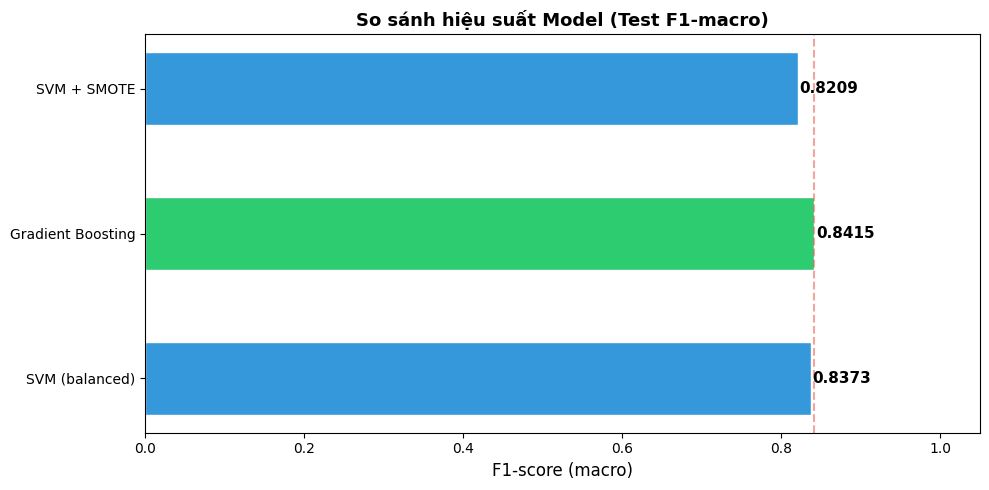

💾 Đã lưu model_comparison.png


In [12]:
results = {
    'SVM (balanced)': f1_svm,
    # 'Random Forest': f1_rf,
    'Gradient Boosting': f1_gb,
    'SVM + SMOTE': f1_smote
}

print('\n' + '='*45)
print('🏅 BẢNG SO SÁNH MODEL')
print('='*45)
best_name = max(results, key=results.get)
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    marker = ' ← 🥇 BEST' if name == best_name else ''
    print(f'  {name:25s}: {score:.4f}{marker}')
print('='*45)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
scores = list(results.values())
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]
bars = ax.barh(names, scores, color=colors, edgecolor='white', height=0.5)
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score (macro)', fontsize=12)
ax.set_title('So sánh hiệu suất Model (Test F1-macro)', fontsize=13, fontweight='bold')
ax.axvline(x=scores[names.index(best_name)], color='#e74c3c', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print('💾 Đã lưu model_comparison.png')

## 💾 10. Lưu Model tốt nhất

In [13]:
import joblib, os

save_dir = '../saved_models'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'best_model.pkl')
joblib.dump(gb, model_path)
print(f'✅ Đã lưu best model: {best_name}')
print(f'   → {model_path}')
print(f'   F1-macro (test): {results[best_name]:.4f}')

# Lưu meta info
import json
meta = {
    'best_model': best_name,
    'f1_macro_test': results[best_name],
    'all_results': {k: round(v, 4) for k, v in results.items()},
    'n_classes': len(sorted(y_clean.unique())),
    'classes': sorted(int(c) for c in y_clean.unique())
}
with open(os.path.join(save_dir, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('📋 Đã lưu model_meta.json')

✅ Đã lưu best model: Gradient Boosting
   → ../saved_models\best_model.pkl
   F1-macro (test): 0.8415
📋 Đã lưu model_meta.json
